## Day 21

- Starting from today we will work on Airbnb_open_data.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Airbnb_open_data_processed.csv")

In [3]:
df.shape

(102591, 24)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102591 entries, 0 to 102590
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102591 non-null  int64  
 1   NAME                            102591 non-null  object 
 2   host id                         102591 non-null  int64  
 3   host_identity_verified          102591 non-null  object 
 4   host name                       102591 non-null  object 
 5   neighbourhood group             102591 non-null  object 
 6   neighbourhood                   102591 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country code                    102591 non-null  object 
 10  instant_bookable                102591 non-null  object 
 11  cancellation_policy             102591 non-null  object 
 12  room type       

In [5]:
df.describe(include='all')

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country code,...,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,has_reviews
count,1.025910e+05,102591,1.025910e+05,102591,102591,102591,102591,102591.000000,102591.000000,102591,...,102591.000000,102591.000000,102591.000000,102591.000000,86699,102591.000000,102591.000000,102591.000000,102591.000000,102591.000000
unique,NaN,61274,NaN,3,13191,8,225,NaN,NaN,2,...,NaN,NaN,NaN,NaN,2476,NaN,NaN,NaN,NaN,NaN
top,NaN,Unknown,NaN,unconfirmed,Michael,Manhattan,Bedford-Stuyvesant,NaN,NaN,US,...,NaN,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN,NaN,NaN
freq,NaN,250,NaN,51195,881,43788,7937,NaN,NaN,102460,...,NaN,NaN,NaN,NaN,2443,NaN,NaN,NaN,NaN,NaN
mean,2.914839e+07,NaN,4.925518e+10,NaN,NaN,NaN,NaN,40.728094,-73.949644,NaN,...,625.297580,125.028268,8.115332,27.434102,NaN,1.161426,3.278280,7.915568,140.934819,0.845094
std,1.625630e+07,NaN,2.853926e+10,NaN,NaN,NaN,NaN,0.055857,0.049521,NaN,...,331.277918,66.238593,30.495645,49.478291,NaN,1.680970,1.282689,32.172170,135.174538,0.361817
min,1.001254e+06,NaN,1.236005e+08,NaN,NaN,NaN,NaN,40.499790,-74.249840,NaN,...,50.000000,10.000000,-1223.000000,0.000000,NaN,0.000000,1.000000,1.000000,-10.000000,0.000000
25%,1.508913e+07,NaN,2.458341e+10,NaN,NaN,NaN,NaN,40.688740,-73.982580,NaN,...,341.000000,68.000000,2.000000,1.000000,NaN,0.090000,2.000000,1.000000,3.000000,1.000000
50%,2.913881e+07,NaN,4.911839e+10,NaN,NaN,NaN,NaN,40.722290,-73.954440,NaN,...,624.000000,125.000000,3.000000,7.000000,NaN,0.480000,3.000000,1.000000,96.000000,1.000000
75%,4.320230e+07,NaN,7.399736e+10,NaN,NaN,NaN,NaN,40.762760,-73.932350,NaN,...,912.000000,182.000000,5.000000,30.000000,NaN,1.710000,4.000000,2.000000,268.000000,1.000000


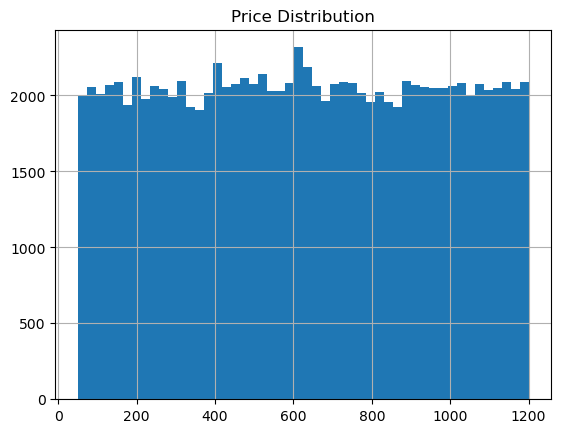

In [7]:
import matplotlib.pyplot as plt

df['price'].hist(bins=50)
plt.title("Price Distribution")
plt.show()

Price does not follow a normal distribution, suggesting possible preprocessing, capping, or dataset bias. Log transformation may not add value here, but outlier checks are still required.

In [10]:
df['room type'].value_counts(normalize=True)

room type
Entire home/apt    0.523428
Private room       0.453744
Shared room        0.021698
Hotel room         0.001131
Name: proportion, dtype: float64

In [11]:
df['neighbourhood group'].value_counts()

neighbourhood group
Manhattan        43788
Brooklyn         41839
Queens           13266
Bronx             2712
Staten Island      955
Unknown             29
manhatan             1
brookln              1
Name: count, dtype: int64

In [13]:
df.groupby('room type')['price'].median().sort_values()

room type
Entire home/apt    624.0
Private room       624.0
Hotel room         644.5
Shared room        649.5
Name: price, dtype: float64

In [14]:
df.groupby('neighbourhood group')['price'].mean().sort_values()

neighbourhood group
manhatan         460.000000
brookln          580.000000
Manhattan        622.457089
Staten Island    624.489005
Brooklyn         626.550730
Bronx            627.756637
Queens           630.222825
Unknown          657.172414
Name: price, dtype: float64

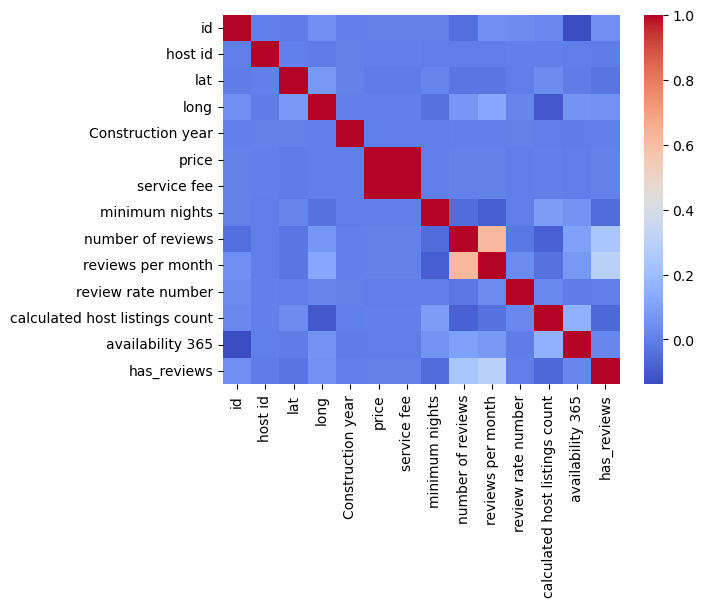

In [15]:
import seaborn as sns

num_cols = df.select_dtypes(include='number')
sns.heatmap(num_cols.corr(), cmap='coolwarm')
plt.show()

Strong correlations
`
price ↔ service fee → almost perfect correlation
- Business insight: service fee is derived from price → one of them is redundant
- ML decision: drop one to avoid multicollinearity

number of reviews ↔ reviews per month
- makes sense historically
- both capture popularity → can engineer a new feature later

availability_365 ↔ has_reviews (negative-ish)
- listings with reviews tend to be booked more
- this is a business insight, not just ML

Weak / near-zero correlations

lat, long with price
- location alone isn’t enough
- need neighbourhood encoding later

In [17]:
df['price'].quantile([0.95, 0.99])

0.95    1143.0
0.99    1188.0
Name: price, dtype: float64

### Key EDA Findings
- Service fee is highly correlated with price → potential feature redundancy
- Review-related features show strong internal correlation
- Location coordinates alone do not strongly influence price
- Price distribution is unusually uniform → dataset bias possible